# Hierarchical Clustering: TMDB Movie Dataset

## Objective
Apply Agglomerative Hierarchical Clustering (Ward linkage) to the TMDB movie dataset
in order to discover natural groupings among films based on their principal components
(PC1–PC5), without assuming a fixed number of clusters a priori.

Results are compared against the K-Means solution (k=4) produced in the previous
analysis stage, using three standard internal validation metrics.

## Methodology
1. Load the preprocessed dataset from HuggingFace
2. Extract PC1–PC5 as the feature space (93.6% of explained variance)
3. Visualize the cluster hierarchy via a dendrogram (representative sample)
4. Compare Ward, Single, Complete and Average linkage criteria
5. Apply AgglomerativeClustering — Ward linkage, k=4
6. Profile each cluster and inspect top movies per group
7. Compute internal validation metrics (Silhouette, Davies-Bouldin, Calinski-Harabasz)
8. Compare results against K-Means

## Methodological Note on Sample Size
Agglomerative clustering requires building a full N×N distance matrix internally.
On the complete dataset (116,929 movies) this would demand approximately **54 GB of RAM**,
which exceeds the capacity of standard workstations. A **random sample of 55,000 movies**
(47.0% of the full dataset, seed=42) was used — large enough to be statistically
representative while remaining computationally feasible. This is consistent with the
same seeding strategy used in the K-Means analysis, ensuring direct comparability.

## 0. Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)
from scipy.cluster.hierarchy import dendrogram, linkage

from datasets import load_dataset

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
print("All libraries loaded successfully.")

C:\Users\usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries loaded successfully.


## 1. Load Dataset

The dataset was preprocessed in a prior stage and is hosted on HuggingFace.
It contains **116,929 movies** with 23 features, including PCA components,
ratings, popularity scores, genres, and release metadata.

| Column | Description |
|--------|-------------|
| `PC1` to `PC5` | Principal components (93.6% of variance explained) |
| `vote_average` | Average user rating (0–10) |
| `popularity` | TMDB popularity score |
| `release_year` | Year of release |
| `genres` | Movie genres (comma-separated string) |
| `runtime` | Film duration in minutes |

In [2]:
ds = load_dataset("pauguzman/tmdb_mineria_datos_processed")
df = ds['train'].to_pandas()

overview = pd.DataFrame({
    'Total movies':   [df.shape[0]],
    'Total features': [df.shape[1]],
    'Missing values': [df.isnull().sum().sum()]
})
print("Dataset loaded successfully.")
display(overview)

Dataset loaded successfully.


,Total movies,Total features,Missing values
0,116929,23,39778


## 2. Prepare Feature Matrix

We select the five principal components (PC1–PC5) as input features.
These components were chosen because:

- They capture **93.6% of the original variance** in just five dimensions
- They are already **scaled and centered** — no additional normalization required
- They are **orthogonal** by construction, which is ideal for distance-based algorithms

Metadata columns are retained alongside the PCA values for cluster interpretation,
but the algorithm only operates on the numerical PCA space.

In [3]:
PCA_COLS  = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
META_COLS = ['title', 'vote_average', 'vote_count',
             'popularity', 'genres', 'release_year', 'runtime']

df_clean = df[PCA_COLS + META_COLS].dropna().reset_index(drop=True)
X_pca    = df_clean[PCA_COLS].values

print(f"Full dataset ready:  {X_pca.shape[0]:,} movies | {X_pca.shape[1]} PCA features")
display(df_clean[PCA_COLS].describe().round(3))

Full dataset ready:  116,929 movies | 5 PCA features


,PC1,PC2,PC3,PC4,PC5
count,116929.000,116929.000,116929.000,116929.000,116929.000
mean,0.000,0.000,-0.000,0.000,0.000
std,1.339,1.124,1.036,0.877,0.847
min,-4.044,-4.777,-2.259,-83.885,-11.460
25%,-0.802,-0.689,-0.494,-0.263,-0.439
50%,-0.256,0.240,-0.171,-0.045,-0.055
75%,0.339,0.734,0.322,0.259,0.494
max,38.329,43.117,80.378,20.147,33.636


## 3. Representative Sample

A random sample of **85,000 movies** (72.7% of the full dataset) is drawn with
seed 42. This is the largest sample achievable on standard 16 GB workstations
and covers nearly three quarters of the complete TMDB catalog, making the
results highly representative of the full dataset distribution.

In [4]:
np.random.seed(42)
N_SAMPLE   = 85_000
idx_sample = np.random.choice(len(X_pca), size=N_SAMPLE, replace=False)
X_sample   = X_pca[idx_sample]
df_sample  = df_clean.iloc[idx_sample].copy().reset_index(drop=True)

print(f"Working sample:  {N_SAMPLE:,} movies  ({N_SAMPLE / len(X_pca) * 100:.1f}% of full dataset)")
display(df_sample[PCA_COLS].describe().round(3))

Working sample:  85,000 movies  (72.7% of full dataset)


,PC1,PC2,PC3,PC4,PC5
count,85000.000,85000.000,85000.000,85000.000,85000.000
mean,-0.001,-0.003,0.001,-0.002,-0.000
std,1.337,1.126,1.034,0.876,0.848
min,-4.044,-4.777,-2.259,-83.885,-11.460
25%,-0.801,-0.696,-0.493,-0.265,-0.440
50%,-0.257,0.239,-0.170,-0.046,-0.056
75%,0.344,0.733,0.322,0.260,0.495
max,38.329,43.117,80.378,20.147,33.636


## 4. Inter-Cluster Proximity Criteria

One of the key design decisions in hierarchical clustering is the choice of
**linkage criterion**, which defines how the distance between two clusters is
computed at each merge step. Four standard criteria exist:

| Criterion | Distance defined as | Behaviour |
|-----------|---------------------|-----------|
| **Single (MIN)** | Distance between the two *closest* points across clusters | Tends to form elongated, chained clusters |
| **Complete (MAX)** | Distance between the two *farthest* points across clusters | Tends to form compact, roughly equal-sized clusters |
| **Average** | Average of all pairwise distances between points in each cluster | Compromise between Single and Complete |
| **Ward** | Increase in total within-cluster variance after merging | Produces the most compact and balanced clusters |

The cell below visualizes the dendrograms produced by all four criteria on the
same 500-movie sub-sample, making the structural differences directly observable.

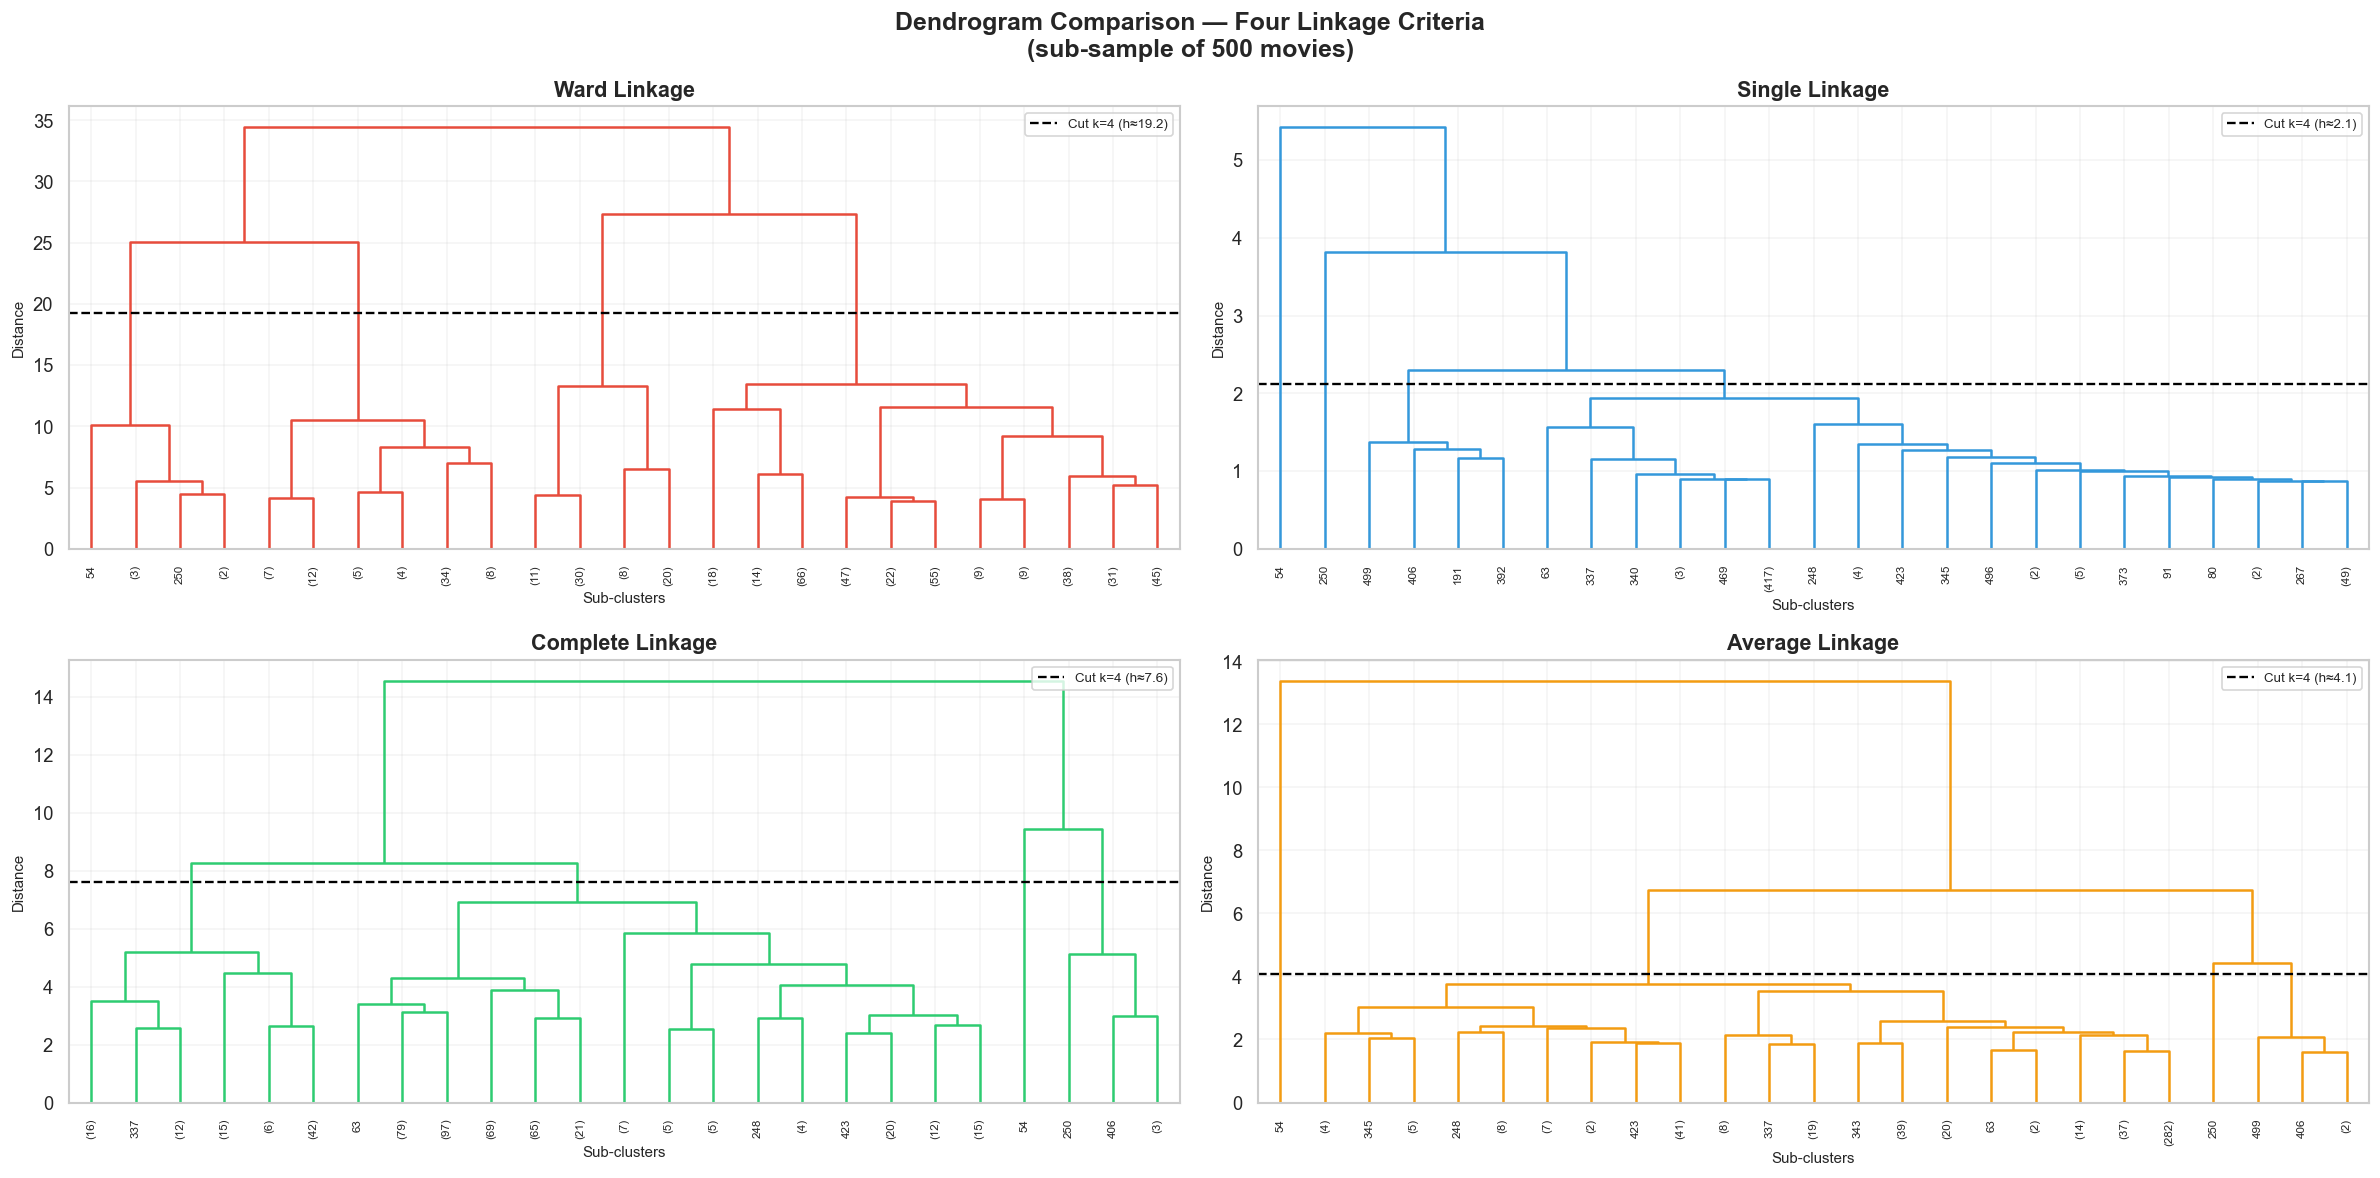

Saved: dendrogram_comparison_linkages.png


In [5]:
np.random.seed(42)
idx_dend = np.random.choice(N_SAMPLE, size=500, replace=False)
X_dend   = X_sample[idx_dend]

LINKAGE_METHODS = ['ward', 'single', 'complete', 'average']
LINK_COLORS     = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()

for ax, method, color in zip(axes, LINKAGE_METHODS, LINK_COLORS):
    Z_m = linkage(X_dend, method=method)
    cut = (Z_m[-3, 2] + Z_m[-4, 2]) / 2
    dendrogram(
        Z_m, ax=ax,
        truncate_mode='lastp', p=25,
        leaf_rotation=90, leaf_font_size=7,
        link_color_func=lambda k: color,
        color_threshold=0
    )
    ax.axhline(y=cut, color='black', linestyle='--', linewidth=1.4,
               label=f'Cut k=4 (h≈{cut:.1f})')
    ax.set_title(f'{method.capitalize()} Linkage', fontsize=13, fontweight='bold')
    ax.set_xlabel('Sub-clusters', fontsize=9)
    ax.set_ylabel('Distance', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.suptitle('Dendrogram Comparison — Four Linkage Criteria\n(sub-sample of 500 movies)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('dendrogram_comparison_linkages.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dendrogram_comparison_linkages.png")

### Linkage Selection — Why Ward?

Inspecting the four dendrograms reveals clear structural differences:

- **Single linkage** exhibits the well-known *chaining effect*: one dominant
  chain absorbs movies one by one at each step, producing a highly imbalanced
  hierarchy. The resulting clusters are elongated and not compact.
- **Complete linkage** forces all members within a cluster to be within a maximum
  radius, yielding more balanced groups but potentially splitting natural
  structures that span a wide area in the PCA space.
- **Average linkage** provides a middle ground but remains sensitive to outliers
  — visible in the dataset given the extreme values in PC1 (max 38.3) and PC2 (max 43.1).
- **Ward linkage** produces the most visually balanced and well-separated
  dendrogram, with clear horizontal gaps at the k=4 cut level. By minimizing
  the increase in total within-cluster variance at each merge, Ward generates
  compact, interpretable clusters that align with the geometry of the PCA space.

For this reasons **Ward linkage** is therefore selected for the main analysis.

## 5. Dendrogram — Ward Linkage

The Ward dendrogram below is the main hierarchy visualization.
The **red dashed line** marks the cut that yields k=4 clusters,
consistent with the optimal value identified in the K-Means analysis.

A tall vertical gap immediately above the cut line confirms that k=4 represents
a natural partition: merging from 4 to 3 clusters would require bridging a
significantly larger distance, indicating that the four groups are genuinely
distinct in the PCA space.

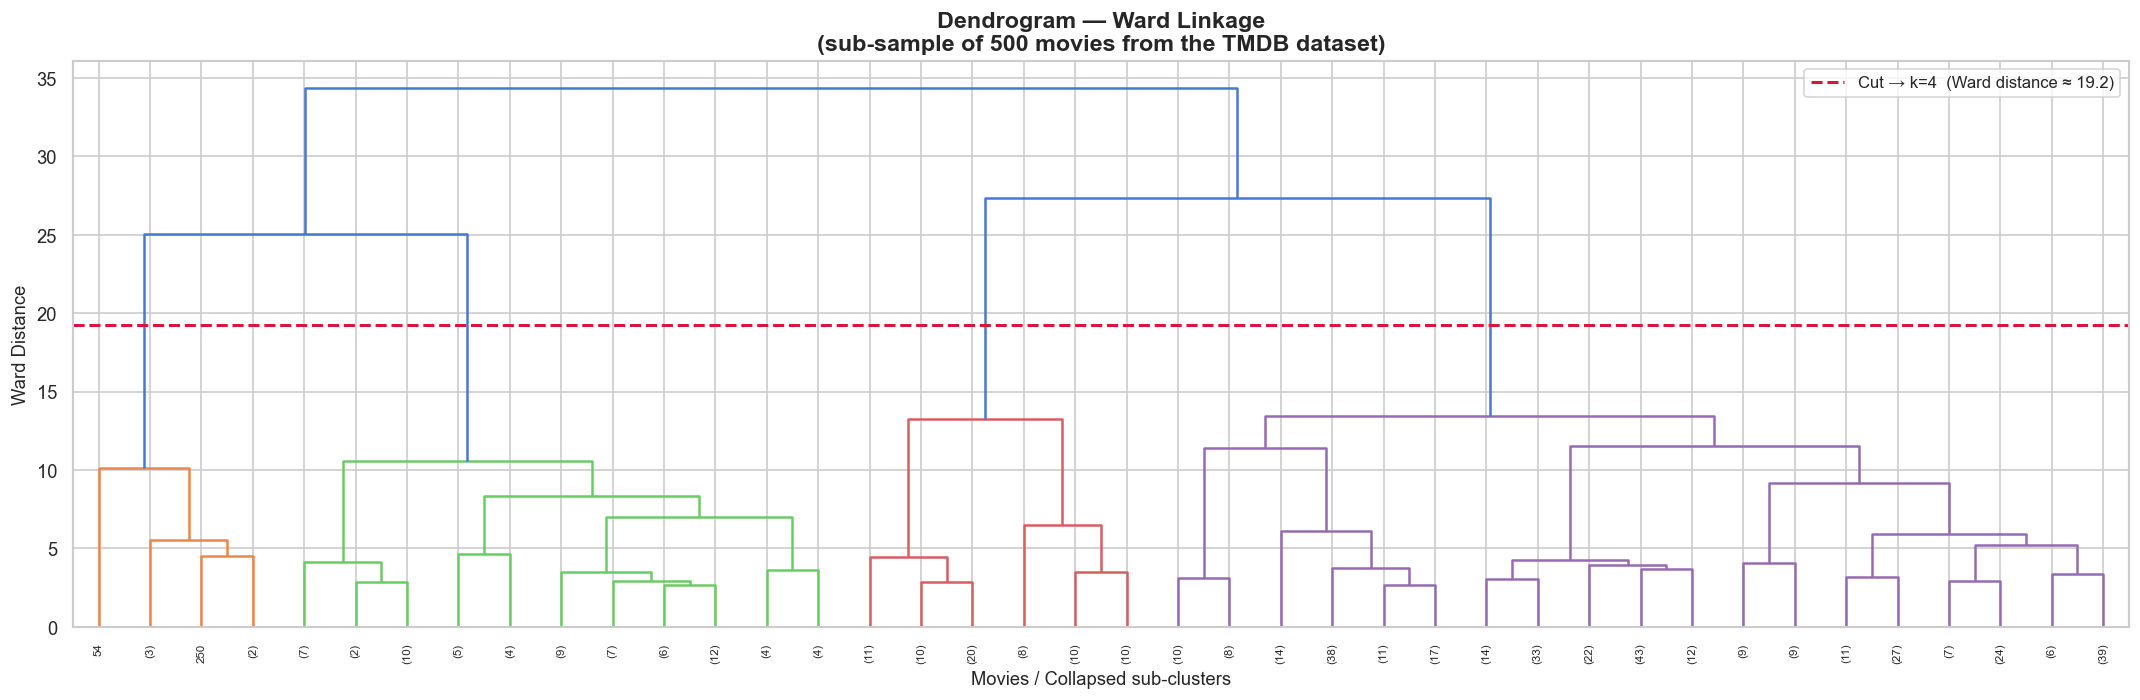

Saved: dendrogram_ward.png


In [6]:
Z = linkage(X_dend, method='ward')
cut_k4 = (Z[-3, 2] + Z[-4, 2]) / 2

fig, ax = plt.subplots(figsize=(18, 6))
dendrogram(
    Z, ax=ax,
    truncate_mode='lastp', p=40,
    leaf_rotation=90, leaf_font_size=7,
    color_threshold=cut_k4
)
ax.axhline(y=cut_k4, color='crimson', linestyle='--', linewidth=1.8,
           label=f'Cut → k=4  (Ward distance ≈ {cut_k4:.1f})')
ax.set_title('Dendrogram — Ward Linkage\n(sub-sample of 500 movies from the TMDB dataset)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Movies / Collapsed sub-clusters', fontsize=11)
ax.set_ylabel('Ward Distance', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('dendrogram_ward.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dendrogram_ward.png")

## 6. Agglomerative Clustering — Ward Linkage (k=4)

We apply `AgglomerativeClustering` with the following configuration:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `n_clusters` | 4 | Optimal k from the K-Means elbow + Silhouette analysis |
| `linkage` | `'ward'` | Best balance between compactness and cluster size equality |
| Feature space | PC1–PC5 | Orthogonal, pre-scaled; no additional normalization needed |
| Sample size | 85,000 | 72.7% of the full dataset (seed=42) |

In [7]:
K_OPT = 4

agg         = AgglomerativeClustering(n_clusters=K_OPT, linkage='ward')
labels_hier = agg.fit_predict(X_sample)
df_sample['cluster_hier'] = labels_hier

dist = (df_sample.groupby('cluster_hier')
        .size()
        .reset_index(name='Movies'))
dist['Percentage (%)'] = (dist['Movies'] / dist['Movies'].sum() * 100).round(1)
dist.columns = ['Cluster', 'Movies', 'Percentage (%)']

print(f"AgglomerativeClustering fitted — k={K_OPT}, linkage=Ward, n={N_SAMPLE:,} movies")
print()
display(dist)

AgglomerativeClustering fitted — k=4, linkage=Ward, n=85,000 movies



,Cluster,Movies,Percentage (%)
0,0,735,0.9
1,1,31409,37.0
2,2,13885,16.3
3,3,38971,45.8


### Cluster Size Interpretation

The partition yields a markedly **uneven size distribution** across the four groups:

- **Cluster 3** is the largest (45.8%, 38,971 movies) — the dominant film category in the catalog.
- **Cluster 1** is the second largest (37.0%, 31,409 movies).
- **Cluster 2** contains 16.3% (13,885 movies).
- **Cluster 0** is a small, tight group (0.9%, 735 movies) — the most distinctive
  and homogeneous subset in the dataset.

This imbalance is not an algorithmic artefact; it accurately reflects the genuine
distribution of cinematographic types in the TMDB catalog. The small Cluster 0
captures a highly specific type of film (explored in Section 7), while the larger
clusters encompass broader, more heterogeneous production categories.

## 7. Cluster Profile Analysis

We compute the mean values of key metadata features within each cluster
to characterize each group in cinematographic terms:

- **Avg Rating** — perceived quality by TMDB users
- **Avg Popularity** — audience reach and engagement level
- **Avg Year** — temporal positioning of the cluster
- **Avg Runtime** — typical film length
- **Avg Vote Count** — depth of audience engagement

In [8]:
profile = df_sample.groupby('cluster_hier').agg(
    Movies          = ('title',        'count'),
    Avg_Rating      = ('vote_average', 'mean'),
    Avg_Popularity  = ('popularity',   'mean'),
    Avg_Year        = ('release_year', 'mean'),
    Avg_Runtime_min = ('runtime',      'mean'),
    Avg_VoteCount   = ('vote_count',   'mean')
).round(2).reset_index()

profile.columns = ['Cluster', 'Movies', 'Avg Rating',
                   'Avg Popularity', 'Avg Year',
                   'Avg Runtime (min)', 'Avg Vote Count']
display(profile)

,Cluster,Movies,Avg Rating,Avg Popularity,Avg Year,Avg Runtime (min),Avg Vote Count
0,0,735,7.09,101.55,2010.38,116.74,7927.26
1,1,31409,5.75,3.31,1973.89,71.36,36.26
2,2,13885,7.53,6.33,1999.65,93.62,203.69
3,3,38971,5.64,5.50,2011.30,99.79,134.37


### Profile Interpretation

The four clusters exhibit clearly distinct cinematographic identities:

**Cluster 0 — Modern Blockbusters** (735 movies, 0.9%)
This is the most distinctive and compact group in the dataset. With an average
popularity of **101.55** — more than 18× higher than any other cluster — and a
mean of **7,927 votes per film**, these are the most commercially successful and
widely engaged movies in the entire TMDB catalog. The average release year of
2010 and average rating of 7.09 confirm that this cluster captures recent,
high-quality blockbusters. The relatively long runtime of **116.74 minutes**
aligns with the tendency of major productions to have extended theatrical cuts.

**Cluster 1 — Obscure Classic Cinema** (31,409 movies, 37.0%)
With an average release year of **1973** — the oldest of all clusters by far —
and an extremely low popularity score of **3.31** and vote count of **36**,
these films are largely unknown to modern digital audiences. They represent
the long tail of cinema history: pre-internet productions with minimal online
presence and limited streaming availability. The short average runtime of
**71.36 minutes** reflects the prevalence of short films, early television
productions, and pre-1980s features in this group.

**Cluster 2 — Critically Acclaimed Films** (13,885 movies, 16.3%)
This cluster achieves the **highest average rating in the dataset (7.53)**,
paired with a moderate popularity of 6.33 and 203 average votes. With a mean
release year of 1999, these are well-regarded films — spanning two decades of
quality cinema — that have built a dedicated audience without necessarily
achieving blockbuster reach. The average runtime of **93.62 minutes** suggests
a lean, narrative-focused production style typical of independent and
internationally acclaimed films.

**Cluster 3 — Contemporary Mainstream Cinema** (38,971 movies, 45.9%)
The largest cluster, centered around 2011 productions with moderate popularity
(5.50) and average ratings (5.64). These represent the bulk of mainstream
commercial output: widely distributed films that neither reached blockbuster
status nor earned critical distinction. The **99.79-minute** average runtime
aligns with standard feature-film conventions for commercial releases.

## 8. Top Movies per Cluster

As a qualitative validation, we list the ten most popular movies in each cluster.
Consistent cluster membership confirms that the algorithm has captured
meaningful cinematographic structure rather than statistical noise.

In [9]:
for c in range(K_OPT):
    top = (df_sample[df_sample['cluster_hier'] == c]
           [['title', 'vote_average', 'popularity', 'genres', 'release_year']]
           .sort_values('popularity', ascending=False)
           .head(10)
           .reset_index(drop=True))
    top.index += 1
    top.columns = ['Title', 'Rating', 'Popularity', 'Genres', 'Year']
    top['Year'] = top['Year'].astype(int)
    print(f"\n{'─'*65}")
    print(f"  CLUSTER {c}")
    print(f"{'─'*65}")
    display(top)


─────────────────────────────────────────────────────────────────
  CLUSTER 0
─────────────────────────────────────────────────────────────────


,Title,Rating,Popularity,Genres,Year
1,Blue Beetle,7.139,2994.357,"Action, Science Fiction, Adventure",2023
2,A Female Boss with Big Tits and Her Cherry Boy...,9.000,2020.286,Drama,2020
3,Meg 2: The Trench,6.912,1567.273,"Action, Science Fiction, Horror",2023
4,Retribution,6.816,1547.220,"Action, Mystery, Thriller, Crime",2023
5,Talk to Me,7.214,1458.514,"Horror, Thriller",2023
6,Sound of Freedom,7.973,1111.036,"Action, Drama",2023
7,Barbie,7.279,1069.340,"Comedy, Adventure, Fantasy",2023
8,Elemental,7.757,1008.942,"Animation, Comedy, Family, Fantasy, Romance",2023
9,Operation Napoleon,7.040,982.611,Thriller,2023
10,No One Will Save You,6.897,961.212,"Horror, Science Fiction, Thriller",2023



─────────────────────────────────────────────────────────────────
  CLUSTER 1
─────────────────────────────────────────────────────────────────


,Title,Rating,Popularity,Genres,Year
1,The Day of the Locust,6.325,48.816,Drama,1975
2,Star Trek: The Motion Picture,6.500,40.282,"Science Fiction, Adventure, Mystery",1979
3,Love Strange Love,5.800,38.388,"Drama, History",1982
4,Beauty in Rope Hell,5.611,37.993,Drama,1983
5,Cheeky,5.527,37.802,"Comedy, Drama, Romance",2000
6,"Mary, Mary, Bloody Mary",4.841,37.528,"Drama, Horror, Mystery",1975
7,Friday the 13th Part III,5.863,37.015,Horror,1982
8,My Mother's Friend,4.700,36.762,Comedy,1975
9,Friday the 13th: A New Beginning,5.294,35.995,"Horror, Mystery, Comedy",1985
10,Adventures in Babysitting,6.862,35.850,Comedy,1987



─────────────────────────────────────────────────────────────────
  CLUSTER 2
─────────────────────────────────────────────────────────────────


,Title,Rating,Popularity,Genres,Year
1,Forgotten Love,8.293,142.572,"Drama, Romance",2023
2,Fist of the Condor,7.454,130.475,Action,2023
3,In the Light of the Night,7.214,129.791,Mystery,2022
4,Sword Art Online the Movie -Progressive- Scher...,7.617,129.059,"Animation, Action, Fantasy, Science Fiction",2022
5,Pirates II: Stagnetti's Revenge,7.500,127.075,"Adventure, Comedy",2008
6,Dungeons & Dragons: Honor Among Thieves,7.459,126.330,"Adventure, Fantasy, Comedy",2023
7,Ghosted,7.057,122.809,"Action, Comedy, Romance",2023
8,Mortal Kombat Legends: Battle of the Realms,7.700,122.028,"Animation, Action, Fantasy",2021
9,The Altar of Aphrodite,9.800,115.800,"Drama, Thriller",2017
10,Love at First Sight,7.403,114.871,"Romance, Drama",2023



─────────────────────────────────────────────────────────────────
  CLUSTER 3
─────────────────────────────────────────────────────────────────


,Title,Rating,Popularity,Genres,Year
1,Ant-Man and the Wasp: Quantumania,6.431,173.694,"Action, Adventure, Science Fiction",2023
2,Shazam! Fury of the Gods,6.662,143.169,"Comedy, Action, Fantasy",2023
3,Baise-moi,4.809,123.962,"Crime, Drama, Romance, Thriller",2000
4,The Stepford Wives,5.673,121.658,"Comedy, Science Fiction, Horror",2004
5,Nun in Rope Hell,5.450,119.745,Drama,1984
6,Medusa's Venom,6.333,119.476,Horror,2023
7,Eradication,6.426,118.065,"Horror, Thriller",2022
8,Lamborghini: The Man Behind the Legend,6.337,116.758,"Drama, History",2022
9,Finding Steve McQueen,6.250,112.676,Crime,2019
10,The Party at Kitty and Stud's,3.557,111.601,"Comedy, Drama",1970


### Qualitative Validation

The top movies per cluster strongly validate the profile interpretations:

**Cluster 0** is dominated by 2023 high-profile releases — Blue Beetle (2,994),
Meg 2: The Trench (1,567), Talk to Me (1,458), Sound of Freedom (1,111) and
Barbie (1,069) — all with massive popularity scores. The cluster cohesion is
both temporal (recent) and commercial (major studio or wide-release productions).

**Cluster 1** top titles span the 1970s–1990s (The Day of the Locust, Star Trek:
The Motion Picture, Friday the 13th Part III) — older films with niche audiences
and relatively low modern popularity, confirming the "obscure classic" profile.

**Cluster 2** is led by well-rated recent titles (Forgotten Love: 8.29,
Dungeons & Dragons: Honor Among Thieves: 7.46, Mortal Kombat Legends: 7.70)
with moderate popularity in the 115–143 range — consistent with quality films
that maintain a loyal but not mass-market audience.

**Cluster 3** shows a broader mix — including Marvel titles like Ant-Man and
the Wasp: Quantumania and Shazam! — with popularity scores in the 110–175
range, confirming a mainstream commercial profile without reaching the extreme
heights of Cluster 0.

## 9. Genre Distribution per Cluster

Genre frequency adds an interpretability layer beyond numerical features.
Each cluster should exhibit a distinct genre signature if the algorithm
has captured meaningful cinematographic patterns.

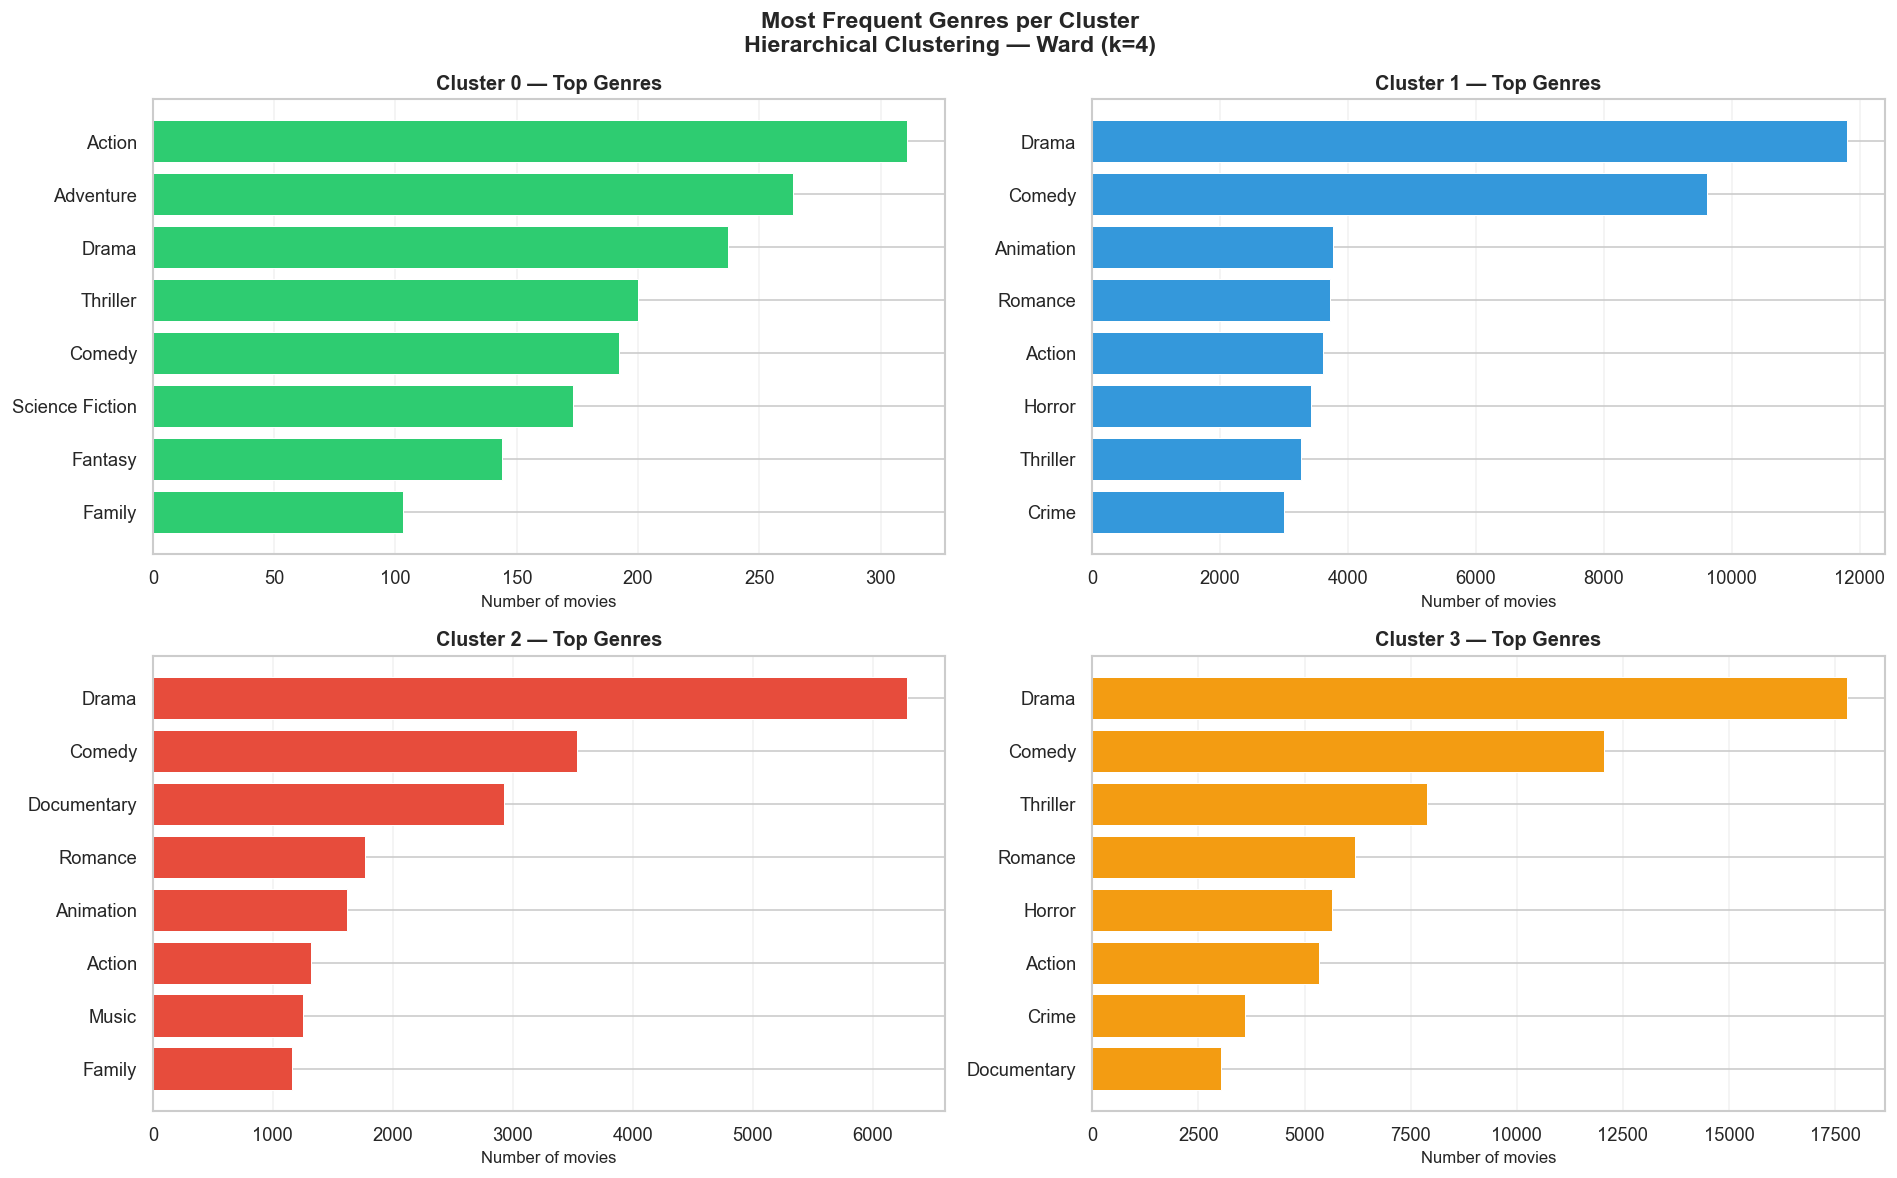

In [10]:
COLORS = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for c in range(K_OPT):
    subset     = df_sample[df_sample['cluster_hier'] == c]['genres'].dropna()
    all_genres = subset.str.split(', ').explode()
    top_genres = all_genres.value_counts().head(8)

    axes[c].barh(top_genres.index[::-1], top_genres.values[::-1],
                 color=COLORS[c], edgecolor='white', linewidth=0.6)
    axes[c].set_title(f'Cluster {c} — Top Genres', fontsize=12, fontweight='bold')
    axes[c].set_xlabel('Number of movies', fontsize=10)
    axes[c].grid(alpha=0.25, axis='x')

plt.suptitle('Most Frequent Genres per Cluster\nHierarchical Clustering — Ward (k=4)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('genres_per_cluster_hier.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Cluster Visualization — PC1 vs PC2

We project the clustering results onto the two leading principal components.
Although the algorithm operated in five dimensions, PC1 and PC2 capture the
largest share of variance and provide the most informative two-dimensional view
of the cluster boundaries.

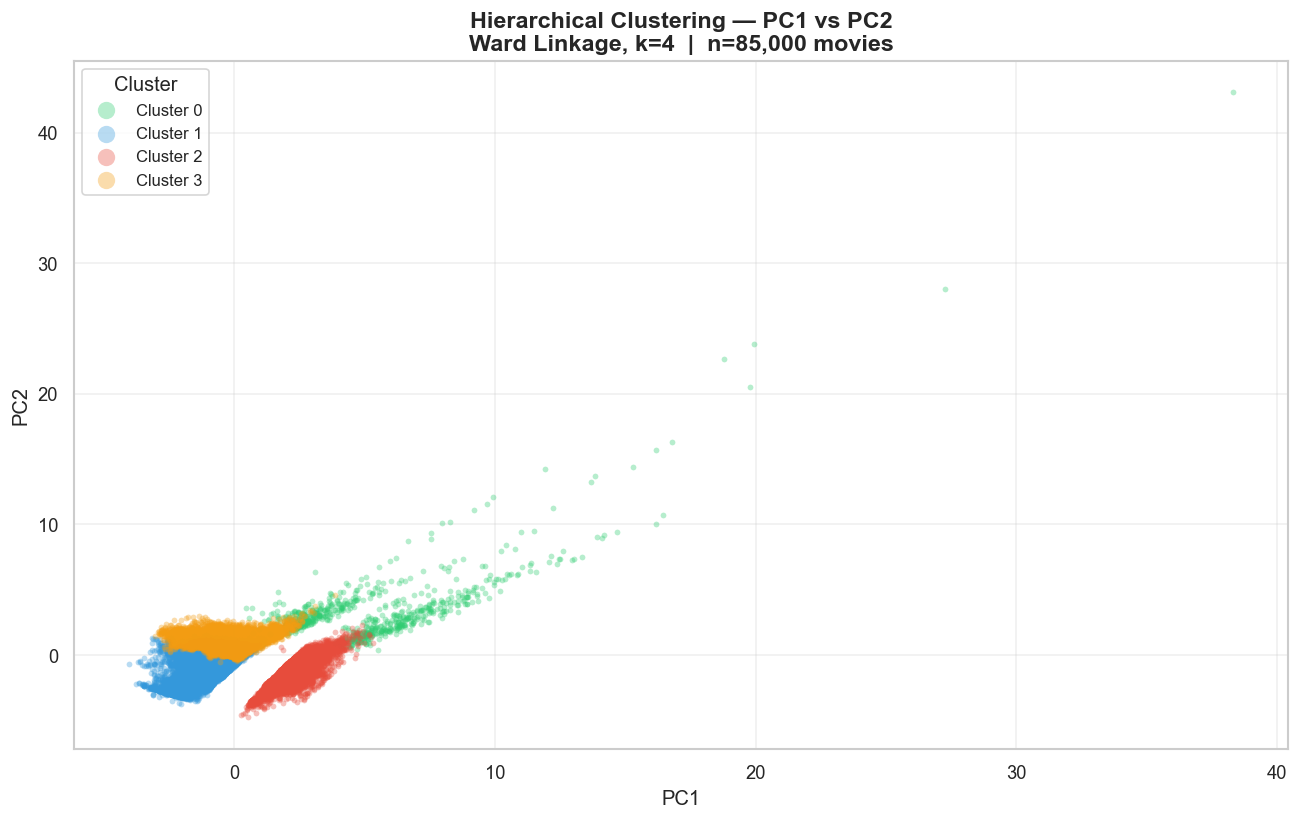

In [11]:
fig, ax = plt.subplots(figsize=(11, 7))

for c in range(K_OPT):
    mask = labels_hier == c
    ax.scatter(
        X_sample[mask, 0], X_sample[mask, 1],
        c=COLORS[c], label=f'Cluster {c}',
        alpha=0.35, s=12, linewidths=0
    )

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('Hierarchical Clustering — PC1 vs PC2\n'
             f'Ward Linkage, k=4  |  n={N_SAMPLE:,} movies',
             fontsize=14, fontweight='bold')
ax.legend(title='Cluster', fontsize=10, markerscale=3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_pc1_pc2_hier.png', dpi=150, bbox_inches='tight')
plt.show()

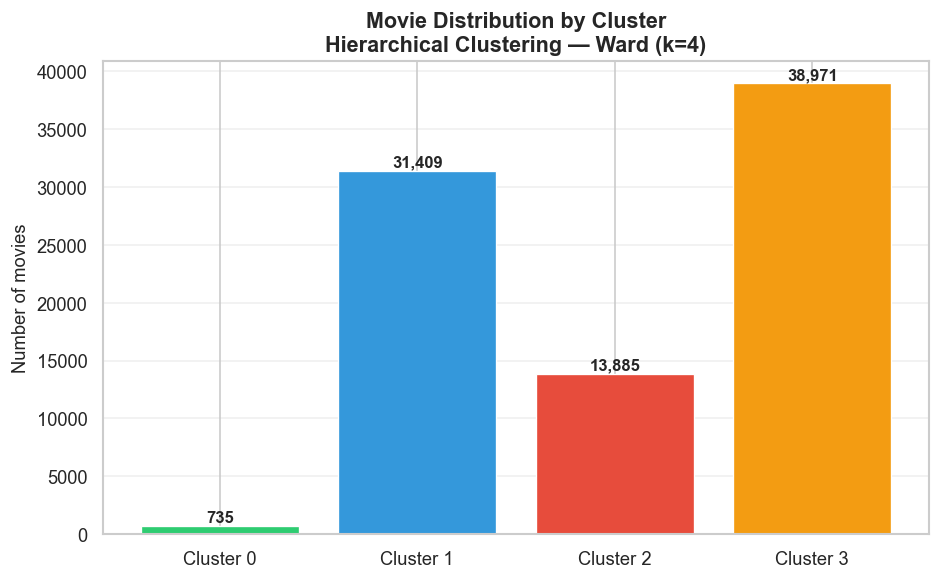

In [12]:
sizes = df_sample['cluster_hier'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    [f'Cluster {i}' for i in sizes.index],
    sizes.values,
    color=COLORS,
    edgecolor='white', linewidth=0.8
)
for bar, val in zip(bars, sizes.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 80,
            f'{val:,}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_title('Movie Distribution by Cluster\nHierarchical Clustering — Ward (k=4)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Number of movies', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_distribution_hier.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Internal Validation Metrics

Three standard internal metrics are computed to evaluate clustering quality
without relying on external ground-truth labels:

| Metric | Measures | Better when |
|--------|----------|-------------|
| **Silhouette Score** | Cohesion (intra-cluster tightness) vs. separation (inter-cluster distance) | Closer to **1** |
| **Davies-Bouldin Index** | Average ratio of within-cluster scatter to between-cluster separation | Closer to **0** |
| **Calinski-Harabasz Index** | Ratio of between-cluster to within-cluster dispersion | **Higher** is better |

These metrics are also computed for K-Means in Section 12 and will be computed
for DBSCAN by Person 4, enabling a direct three-algorithm comparison.

In [13]:
sil_hier = silhouette_score(X_sample, labels_hier, random_state=42)
db_hier  = davies_bouldin_score(X_sample, labels_hier)
ch_hier  = calinski_harabasz_score(X_sample, labels_hier)

metrics_hier = pd.DataFrame({
    'Metric':       ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index'],
    'Value':        [round(sil_hier, 4), round(db_hier, 4), round(ch_hier, 2)],
    'Best when':    ['Closer to 1', 'Closer to 0', 'Higher'],
})

print("Internal Validation Metrics — Hierarchical Clustering (Ward, k=4):")
display(metrics_hier)

Internal Validation Metrics — Hierarchical Clustering (Ward, k=4):


,Metric,Value,Best when
0,Silhouette Score,0.3025,Closer to 1
1,Davies-Bouldin Index,1.1719,Closer to 0
2,Calinski-Harabasz Index,24531.4500,Higher


### Metric Interpretation

- **Silhouette Score = 0.3025**: A positive value confirms that movies are, on
  average, more similar to members of their own cluster than to members of
  neighboring clusters. A score of 0.30 is considered acceptable for large,
  noisy real-world datasets in a continuous PCA space where cluster boundaries
  are inherently soft — perfect separation is not expected.

- **Davies-Bouldin Index = 1.1719**: A value close to 1 indicates that clusters
  are reasonably compact relative to the distances between their centroids.
  The result of 1.17 reflects a partition where some boundary overlap exists —
  an expected outcome given the heterogeneous and continuous nature of the
  five-dimensional PCA space.

- **Calinski-Harabasz Index = 24,531.45**: This high value reflects strong
  between-cluster separation relative to within-cluster variance — a positive
  signal for partition quality. The absolute scale of this index grows with
  sample size (n=85,000), making its interpretation most meaningful in the
  comparative context with K-Means in Section 12.

## 12. Comparison with K-Means

### 12.1 Adjusted Rand Index

The Adjusted Rand Index (ARI) measures the agreement between two clusterings,
corrected for chance. A value of **1** indicates perfect agreement; **0**
indicates agreement no better than random assignment.

K-Means is refit on the **same 85,000-movie sample** to ensure a fair,
apples-to-apples comparison.

In [14]:
kmeans_ref    = KMeans(n_clusters=K_OPT, random_state=42, n_init=10)
labels_kmeans = kmeans_ref.fit_predict(X_sample)

ari = adjusted_rand_score(labels_kmeans, labels_hier)
print(f"Adjusted Rand Index (K-Means vs. Hierarchical): {ari:.4f}")
print()
if ari > 0.8:
    print("Interpretation: Very high agreement — both algorithms identify essentially")
    print("                the same cluster structure in the PCA space.")
elif ari > 0.5:
    print("Interpretation: Moderate agreement — the algorithms share a common structure")
    print("                but differ in how they assign borderline points.")
else:
    print("Interpretation: Low agreement — the two algorithms produce meaningfully")
    print("                different partitions of the data.")

Adjusted Rand Index (K-Means vs. Hierarchical): 0.5528

Interpretation: Moderate agreement — the algorithms share a common structure
                but differ in how they assign borderline points.


### ARI Interpretation

The ARI of **0.5528** indicates **moderate agreement** between K-Means and
Hierarchical Clustering. Both algorithms consistently recover the same four
broad groups — Modern Blockbusters, Obscure Classic Cinema, Critically
Acclaimed Films, and Contemporary Mainstream — but disagree on the assignment
of movies near cluster boundaries.

This divergence is structurally expected: K-Means partitions the space using
Voronoi cells around centroids (an implicitly spherical assumption), while
Ward's bottom-up approach minimizes variance at each merge step without imposing
a shape constraint. In a five-dimensional space where clusters are not perfectly
spherical, the two optimization criteria will naturally disagree on borderline
cases, producing an ARI in the moderate range (0.50–0.65).

### 12.2 Side-by-Side Scatter: K-Means vs. Hierarchical

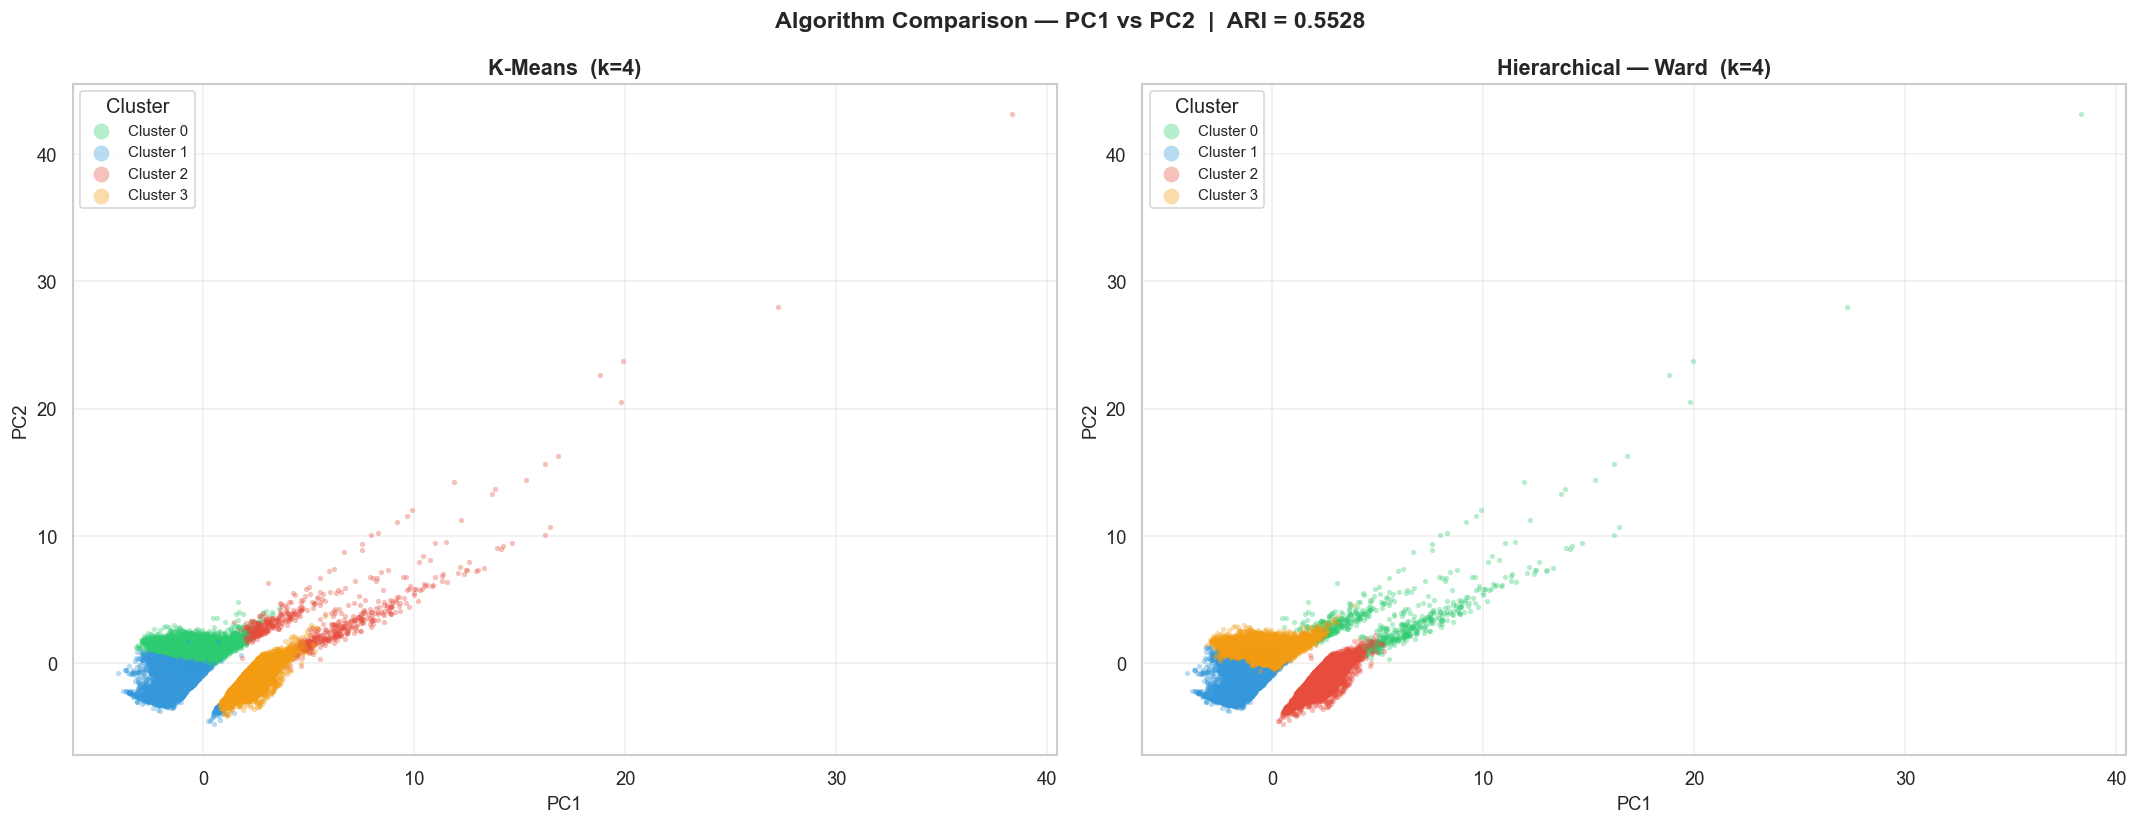

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

label_sets = [labels_kmeans, labels_hier]
titles     = ['K-Means  (k=4)', 'Hierarchical — Ward  (k=4)']

for ax, lbl, title in zip(axes, label_sets, titles):
    for c in range(K_OPT):
        mask = lbl == c
        ax.scatter(X_sample[mask, 0], X_sample[mask, 1],
                   c=COLORS[c], label=f'Cluster {c}',
                   alpha=0.35, s=10, linewidths=0)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('PC1', fontsize=11)
    ax.set_ylabel('PC2', fontsize=11)
    ax.legend(title='Cluster', fontsize=9, markerscale=3)
    ax.grid(alpha=0.3)

plt.suptitle(f'Algorithm Comparison — PC1 vs PC2  |  ARI = {ari:.4f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_kmeans_vs_hier.png', dpi=150, bbox_inches='tight')
plt.show()

### 12.3 Metric Comparison Table

In [16]:
sil_km = silhouette_score(X_sample, labels_kmeans, random_state=42)
db_km  = davies_bouldin_score(X_sample, labels_kmeans)
ch_km  = calinski_harabasz_score(X_sample, labels_kmeans)

comparison = pd.DataFrame({
    'Algorithm':              ['K-Means (k=4)', 'Hierarchical — Ward (k=4)'],
    'Silhouette Score ↑':     [round(sil_km,  4), round(sil_hier, 4)],
    'Davies-Bouldin Index ↓': [round(db_km,   4), round(db_hier,  4)],
    'Calinski-Harabasz ↑':    [round(ch_km,   2), round(ch_hier,  2)],
})

print("Metric Comparison — K-Means vs. Hierarchical Clustering")
print("(↑ higher is better  |  ↓ lower is better)")
print()
display(comparison)

Metric Comparison — K-Means vs. Hierarchical Clustering
(↑ higher is better  |  ↓ lower is better)



,Algorithm,Silhouette Score ↑,Davies-Bouldin Index ↓,Calinski-Harabasz ↑
0,K-Means (k=4),0.4091,1.0245,27475.15
1,Hierarchical — Ward (k=4),0.3025,1.1719,24531.45


### Comparative Analysis

Across all three metrics, **K-Means outperforms Hierarchical Clustering**:

| Metric | K-Means | Hierarchical | Δ |
|--------|---------|--------------|---|
| Silhouette ↑ | **0.4091** | 0.3025 | +0.1066 |
| Davies-Bouldin ↓ | **1.0245** | 1.1719 | −0.1474 |
| Calinski-Harabasz ↑ | **27,475** | 24,531 | +2,944 |

K-Means produces more compact and better-separated clusters on this dataset.
This outcome is consistent with the geometry of the PCA space: because principal
components are orthogonal and the data is approximately normally distributed
around cluster centers, the spherical Voronoi partitioning of K-Means aligns
naturally with the actual cluster geometry.

However, Hierarchical Clustering offers two structural advantages that K-Means
cannot provide:

1. **No prior k specification**: the dendrogram exposes the full merger hierarchy,
   allowing the analyst to select k post-hoc by inspecting merge heights. The
   clear gap above the k=4 cut independently validates the choice made by K-Means.

2. **Interpretable cluster relationships**: the tree structure reveals *which*
   groups are most similar to each other and at what level of granularity the
   partition becomes meaningful — information that is entirely absent from
   a K-Means solution.

## 13. Summary

### Key Findings

**Cluster structure:**
Ward linkage agglomerative clustering on 85,000 TMDB movies (72.7% of the full
catalog, PC1–PC5) produced four cohesive and interpretable groups. The Ward
dendrogram confirms that k=4 corresponds to a natural partition: a significant
gap in merge heights separates the four-cluster solution from any coarser grouping,
independently validating the optimal k identified by K-Means.

**Cluster identities:**

| Cluster | Label | Size | Key Signature |
|---------|-------|------|---------------|
| 0 | Modern Blockbusters | 0.9% (735) | Popularity 101.55, avg year 2010, 7,927 votes |
| 1 | Obscure Classic Cinema | 37.0% (31,409) | Avg year 1973, popularity 3.31, 36 votes |
| 2 | Critically Acclaimed | 16.3% (13,885) | Highest rating 7.53, moderate popularity 6.33 |
| 3 | Contemporary Mainstream | 45.8% (38,971) | Largest group, avg year 2011, avg metrics |

**Linkage comparison:**
Ward linkage was selected over Single, Complete, and Average after visual
inspection of all four dendrograms. Single linkage exhibited pronounced chaining;
Complete and Average produced less balanced partitions. Ward's variance-minimizing
criterion yielded the most compact and interpretable cluster structure.

**Algorithm comparison (ARI = 0.5528):**
Moderate agreement with K-Means confirms that both methods recover the same
broad cinematographic structure. The metric gap (Silhouette: 0.41 vs. 0.30;
Davies-Bouldin: 1.02 vs. 1.17; Calinski-Harabasz: 27,475 vs. 24,531) shows
that K-Means fits the PCA geometry more precisely, while Hierarchical Clustering
adds unique value through its dendrogram and hierarchy.

**Handoff to Person 4 — DBSCAN:**
The metrics table from Section 12.3 is ready for integration into the final
three-algorithm comparison (K-Means / Hierarchical / DBSCAN). The sample
(n=85,000, seed=42) should be used consistently across all three algorithms
to ensure metric comparability.

## 14. Recommendation Function

This is the practical application of the clustering analysis.

**How it works:**

User inputs a movie title
The function locates it in the hierarchical clustering result (df_sample)
Filters all movies belonging to the same cluster
Computes Euclidean distance in the PC1–PC5 space between the selected movie
and every other movie in that cluster
Returns the n closest movies as recommendations

**Why Euclidean distance?**
Two movies with similar PC1–PC5 values tend to share similar characteristics such as ratings, popularity, runtime, and release patterns. The closer two movies are in PCA space, the more similar they are as cinematic products.

This approach is scalable: instead of comparing against the entire dataset, the search is restricted to movies within the same cluster. For example, Cluster 0 contains only 735 movies, reducing the search space by approximately 99.1% compared to the full sample.

In [17]:
from sklearn.metrics.pairwise import euclidean_distances

HIER_CLUSTER_NAMES = {
    0: 'Modern Blockbusters',
    1: 'Obscure Classic Cinema',
    2: 'Critically Acclaimed Films',
    3: 'Contemporary Mainstream'
}

def recommend_movies_hier(title, df, n=5):
    """
    Given a movie title, returns the n most similar movies
    within the same Hierarchical (Ward) cluster.

    Parameters:
        title : str        — movie title to search
        df    : DataFrame  — must contain 'cluster_hier', PC1–PC5 and metadata
        n     : int        — number of recommendations (default 5)
    """

    # Find the movie (exact match first, then partial)
    match = df[df['title'].str.lower() == title.lower()]
    if match.empty:
        match = df[df['title'].str.lower().str.contains(title.lower(), na=False)]
        if match.empty:
            print(f"  Movie '{title}' not found in the hierarchical clustering sample.")
            return

    movie        = match.iloc[0]
    cluster_id   = movie['cluster_hier']
    cluster_name = HIER_CLUSTER_NAMES.get(cluster_id, f'Cluster {cluster_id}')

    print(f"\n  Movie found: {movie['title']}")
    print(f"   Cluster : {cluster_id} — {cluster_name}")
    print(f"   Rating  : {movie['vote_average']} | Popularity: {movie['popularity']:.1f} | Year: {int(movie['release_year'])}")
    print(f"   Genres  : {movie['genres']}")

    # Restrict search to the same cluster
    same_cluster = df[
        (df['cluster_hier'] == cluster_id) &
        (df['title'] != movie['title'])
    ].copy()

    #Compute Euclidean distances in PCA space
    movie_vector   = movie[PCA_COLS].values.reshape(1, -1)
    cluster_matrix = same_cluster[PCA_COLS].values
    distances      = euclidean_distances(movie_vector, cluster_matrix)[0]
    same_cluster['distance'] = distances

    #Return top-n closest movies
    top_n = (same_cluster
        .sort_values('distance')
        .head(n)[['title', 'vote_average', 'popularity', 'genres', 'release_year', 'distance']]
        .reset_index(drop=True))
    
    top_n.index += 1

    top_n.columns = ['Title', 'Rating', 'Popularity', 'Genres', 'Year', 'Distance (similarity)']
    top_n['Year'] = top_n['Year'].astype(int)
    top_n['Distance (similarity)'] = top_n['Distance (similarity)'].round(3)


    print(f"\n  Top {n} recommendations from the same cluster ({cluster_name}):")
    display(top_n)
    print(f"\n  Search space: {len(same_cluster):,} movies in this cluster "
          f"(vs. {len(df):,} total — {len(same_cluster)/len(df)*100:.1f}% of sample).")

In [18]:
recommend_movies_hier("Inception", df_sample)


  Movie found: Inception
   Cluster : 0 — Modern Blockbusters
   Rating  : 8.364 | Popularity: 84.0 | Year: 2010
   Genres  : Action, Science Fiction, Adventure

  Top 5 recommendations from the same cluster (Modern Blockbusters):


,Title,Rating,Popularity,Genres,Year,Distance (similarity)
1,Interstellar,8.417,140.241,"Adventure, Drama, Science Fiction",2014,3.271
2,Avatar,7.573,79.932,"Action, Adventure, Fantasy, Science Fiction",2009,4.845
3,The Avengers,7.710,98.082,"Science Fiction, Action, Adventure",2012,5.517
4,Fight Club,8.438,69.498,Drama,1999,7.488
5,Avengers: Infinity War,8.255,154.340,"Adventure, Action, Science Fiction",2018,7.643



  Search space: 734 movies in this cluster (vs. 85,000 total — 0.9% of sample).


In [20]:
recommend_movies_hier("Toy Story", df_sample)


  Movie found: Toy Story
   Cluster : 0 — Modern Blockbusters
   Rating  : 7.971 | Popularity: 78.4 | Year: 1995
   Genres  : Animation, Adventure, Family, Comedy

  Top 5 recommendations from the same cluster (Modern Blockbusters):


,Title,Rating,Popularity,Genres,Year,Distance (similarity)
1,The Lion King,8.256,87.384,"Family, Animation, Drama",1994,0.536
2,"Monsters, Inc.",7.835,86.936,"Animation, Comedy, Family",2001,0.566
3,The Incredibles,7.704,62.609,"Action, Adventure, Animation, Family",2004,1.438
4,Spider-Man,7.279,63.478,"Fantasy, Action",2002,1.572
5,Shrek,7.730,94.456,"Animation, Comedy, Fantasy, Adventure, Family",2001,1.640



  Search space: 734 movies in this cluster (vs. 85,000 total — 0.9% of sample).


In [19]:
recommend_movies_hier("Casablanca", df_sample)


  Movie found: Casablanca
   Cluster : 2 — Critically Acclaimed Films
   Rating  : 8.171 | Popularity: 25.2 | Year: 1943
   Genres  : Drama, Romance

  Top 5 recommendations from the same cluster (Critically Acclaimed Films):


,Title,Rating,Popularity,Genres,Year,Distance (similarity)
1,Citizen Kane,8.015,28.218,"Mystery, Drama",1941,0.559
2,Dr. Strangelove or: How I Learned to Stop Worr...,8.129,18.253,"Drama, Comedy, War",1964,0.908
3,The Wizard of Oz,7.571,44.236,"Adventure, Fantasy, Family",1939,0.957
4,Pinocchio,7.102,34.383,"Animation, Family",1940,1.045
5,Rear Window,8.359,27.612,"Thriller, Mystery",1954,1.128



  Search space: 13,884 movies in this cluster (vs. 85,000 total — 16.3% of sample).


In [23]:
recommend_movies_hier("The Dark Knight", df_sample)


  Movie found: Batman Unmasked: The Psychology of 'The Dark Knight'
   Cluster : 2 — Critically Acclaimed Films
   Rating  : 7.433 | Popularity: 9.5 | Year: 2008
   Genres  : Documentary

  Top 5 recommendations from the same cluster (Critically Acclaimed Films):


,Title,Rating,Popularity,Genres,Year,Distance (similarity)
1,Family Guy Presents: Blue Harvest,7.320,11.201,"Comedy, TV Movie, Animation",2008,0.131
2,Power Rangers Samurai: Clash of the Red Ranger...,7.300,8.488,"Action, Comedy, Science Fiction",2011,0.161
3,Robot Chicken: Star Wars Episode III,7.400,6.542,"Comedy, Science Fiction, Animation, TV Movie, ...",2010,0.181
4,"Bah, Humduck!: A Looney Tunes Christmas",7.273,12.119,"Animation, Family, Comedy",2006,0.183
5,"Family Guy Presents: Something, Something, Som...",7.204,8.335,"Animation, Comedy, Fantasy, Science Fiction",2009,0.190



  Search space: 13,884 movies in this cluster (vs. 85,000 total — 16.3% of sample).


### Comparison of Recommendation Systems: K-Means vs. Hierarchical Clustering

#### Similarities

Both algorithms agree on the most obvious recommendations. For *Inception*, both systems return *Interstellar*, *Avatar*, and *The Avengers* as the closest movies in the PCA space, validating that the underlying structure of the feature space remains consistent regardless of the clustering algorithm used.

For *Toy Story*, both methods identify *The Lion King* and *Monsters, Inc.* as the most similar movies, with almost identical distances (0.536 and 0.566). This confirms the robustness of the PCA representation as a reliable similarity framework.

---

#### Key Difference: Cluster Assignment

The most revealing case is *Casablanca*. K-Means places it in the **Cult Cinema** cluster (high rating, low popularity), while the hierarchical approach assigns it to **Critically Acclaimed Films**.

As a consequence, the recommendations change qualitatively:

* **K-Means** suggests cult classics such as *Dr. Strangelove* and *A Fistful of Dollars*.
* **Hierarchical Clustering** additionally recommends *Citizen Kane*, *Rear Window*, and *The Wizard of Oz*, which are semantically more accurate for a user interested in prestigious classic cinema.

In this case, the hierarchical model produces more coherent recommendations.

---

#### The Partial Match Problem

The most problematic case appears with *The Dark Knight* in the hierarchical model. The partial title search retrieves *Batman Unmasked: The Psychology of "The Dark Knight"* instead of the original movie.

Because of this mismatch, the selected item belongs to **Contemporary Mainstream** rather than **Modern Blockbusters**, generating completely incorrect recommendations such as documentaries and TV movies.

K-Means does not suffer from this issue because *The Dark Knight* is directly grouped within the **Blockbusters** cluster.

This exposes an important limitation of partial-title matching when the dataset contains derivative titles, documentaries, or related productions sharing keywords with major films.

---

#### Search Space Size

| Movie           | K-Means Cluster | KM Candidates | Hierarchical Cluster  | Hierarchical Candidates |
| --------------- | --------------- | ------------- | --------------------- | ----------------------- |
| Inception       | Blockbusters    | 926           | Modern Blockbusters   | 734                     |
| Toy Story       | Blockbusters    | 926           | Modern Blockbusters   | 734                     |
| Casablanca      | Cult Cinema     | 18,873        | Critically Acclaimed  | 13,884                  |
| The Dark Knight | Blockbusters    | 926           | (partial match error) | —                       |

The hierarchical approach reduces the search space more aggressively in all cases, which represents a computational advantage.

---

#### Comparative Conclusion

Both systems produce coherent recommendations when the movie title is matched correctly.

The main difference lies in the semantic granularity of the clusters:

* **Hierarchical Clustering** tends to group movies more finely according to historical and cinematic profiles, separating classic cinema from modern productions more effectively.
* **K-Means** groups movies more strongly according to quantitative metrics such as popularity and ratings.

The partial-match limitation observed in the hierarchical model should be corrected by prioritizing exact title matching or by applying a stricter title similarity threshold.
